# PCL Detector

We aim to develop a model that can detect patronising and condescending language (PCL) in text, particularly in online news articles about vulnerable communities. This task is important for promoting respectful and inclusive communication, and for identifying and addressing instances of PCL in media coverage.

## Setup

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


In [3]:
import torch
from torch import nn
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
)
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedShuffleSplit

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {DEVICE}")


Device: cuda


In [4]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

class PCLDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def tokenize(texts, tokenizer, max_length=256):
    return tokenizer(
        texts, padding="max_length", truncation=True,
        max_length=max_length, return_tensors="pt"
    )

# 0.5 threshold (argmax): consistent with the weighted focal loss objective.
# The class weight already shifts the decision boundary — threshold should stay at 0.5.
# Using 0.35 + class weights double-compensates and anchors predictions at ~0.325.
PCL_THRESHOLD = 0.5

def _softmax_probs_pcl(logits_array):
    """Stable softmax → probability of PCL class (index 1)."""
    l = logits_array.astype(float)
    e = np.exp(l - l.max(axis=-1, keepdims=True))
    return e[:, 1] / e.sum(axis=-1)

def compute_metrics(eval_pred):
    probs_pcl = _softmax_probs_pcl(eval_pred.predictions)
    preds = (probs_pcl >= PCL_THRESHOLD).astype(int)
    return {"f1_pcl": f1_score(eval_pred.label_ids, preds, pos_label=1, average="binary")}

def print_metrics(trainer, dataset, true_labels, model_name):
    pred_output = trainer.predict(dataset)
    probs_pcl = _softmax_probs_pcl(pred_output.predictions)
    preds = (probs_pcl >= PCL_THRESHOLD).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(true_labels, preds, pos_label=1, average="binary")
    print(f"\n── {model_name} ─────────────────────")
    print(f"  Precision (PCL): {p:.4f}")
    print(f"  Recall    (PCL): {r:.4f}")
    print(f"  F1        (PCL): {f1:.4f}")
    print(f"\n{classification_report(true_labels, preds, target_names=['No PCL', 'PCL'])}")
    return f1


In [5]:
PCL_TSV        = "assets/NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
CATEGORIES_TSV = "data/train/dontpatronizeme_categories.tsv"
TRAIN_SPLIT    = "data/splits/train_semeval_parids-labels.csv"
DEV_SPLIT      = "data/splits/dev_semeval_parids-labels.csv"

### Data Preprocessing

In [6]:
# ── Load PCL binary dataset (skip 4-line disclaimer header) ───────────────────
def load_pcl_dataset(tsv_path):
    df_pcl = pd.read_csv(
        tsv_path, sep="\t", skiprows=4, header=None,
        names=["par_id", "art_id", "keyword", "country_code", "text", "label"]
    )
    df_pcl["par_id"] = df_pcl["par_id"].astype(int)
    df_pcl["label"]  = df_pcl["label"].astype(int)
    return df_pcl

def load_categories_dataset(tsv_path):
    df_cat = pd.read_csv(
        tsv_path, sep="\t", skiprows=4, header=None,
        names=["par_id","art_id","text","keyword","country_code",
               "span_start","span_finish","span_text","pcl_category","num_annotators"]
    )
    return df_cat

The *PCL binary classification dataset* contains paragraphs annotated with a
label from 0 (not containing PCL) to 4 (being highly patronizing or
condescending) towards vulnerable communities. It contains one instance per line
with the following format:	
  - `<par_id>` is a unique id for each one of the paragraphs in the corpus.
  - `<art_id>` is the document id in the original NOW corpus (News on Web:
    https://www.english-corpora.org/now/).
  - `<keyword>` is the search term used to retrieve texts about a target
    community.
  - `<country_code>` is a two-letter ISO Alpha-2 country code for the source media
    outlet.
  - `<text>` is the paragraph containing the keyword.
  - `<label>` is an integer between 0 and 4. Each paragraph has been annotated by
    two annotators as 0 (No PCL), 1 (borderline PCL) and 2 (contains PCL). The
    combined annotations have been used in the following graded scale:
    - 0 -> Annotator 1 = 0 AND Annotator 2 = 0
    - 1 -> Annotator 1 = 0 AND Annotator 2 = 1 OR Annotator 1 = 1 AND Annotator
      2 = 0
    - 2 -> Annotator 1 = 1 AND Annotator 2 = 1
    - 3 -> Annotator 1 = 1 AND Annotator 2 = 2 OR Annotator 1 = 2 AND Annotator
      2 = 1
    - 4 -> Annotator 1 = 2 AND Annotator 2 = 2
- The experiments reported in the paper consider the following tag grouping: 
  - {0,1}   = No PCL
  - {2,3,4} = PCL

The *PCL multilabel classification* dataset contains one instance per line with
the following format:
  - `<par_id>` is a unique id for each one of the paragraphs in the corpus
    (matching the ids of the dontpatronizeme_pcl subdataset).
  - `<art_id>` is the document id in the original NOW corpus (News on Web:
    https://www.english-corpora.org/now/).
  - `<text>` is the paragraph containing the keyword.
  - `<keyword>` is the search term used to retrieve texts about a target
    community.
  - `<country_code>` is a two-letter ISO Alpha-2 country code for the source media
    outlet.
  - `<span_start>` is the start character position of the span identified as pcl.
  - `<span_finish>` is the end character position of the span identified as pcl.
  - `<span_text>` is the span identified as pcl.
  - `<pcl_category>` is the pcl category** of the `<text_span>` at position
    `<text>[<span_start>:<span_finish>]`
  - `<number_of_annotators>` is the number of annotators agreeing on that `<pcl_category>` (1 or 2).

In [7]:
df_pcl = load_pcl_dataset(PCL_TSV)
df_cat = load_categories_dataset(CATEGORIES_TSV)

print(f"\ndf_pcl columns:  {list(df_pcl.columns)}")
print(f"df_cat columns:  {list(df_cat.columns)}")


df_pcl columns:  ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label']
df_cat columns:  ['par_id', 'art_id', 'text', 'keyword', 'country_code', 'span_start', 'span_finish', 'span_text', 'pcl_category', 'num_annotators']


In [8]:
# ── Load SemEval splits ────────────────────────────────────────────────────────
df_train_split = pd.read_csv(TRAIN_SPLIT)
df_dev_split   = pd.read_csv(DEV_SPLIT)

# Parse label vectors
df_train_split["label_vec"] = df_train_split["label"].apply(ast.literal_eval)
df_dev_split["label_vec"]   = df_dev_split["label"].apply(ast.literal_eval)

# ── Attach split membership to PCL dataframe ──────────────────────────────────
train_ids = set(df_train_split["par_id"])
dev_ids   = set(df_dev_split["par_id"])
df_pcl["split"] = df_pcl["par_id"].map(
    lambda x: "train" if x in train_ids else ("dev" if x in dev_ids else "unlabelled")
)
df_split = df_pcl[df_pcl["split"].isin(["train", "dev"])].copy()

# Binary PCL label (0/1) using the {0,1} → No PCL, {2,3,4} → PCL grouping
df_split["pcl"] = (df_split["label"] >= 2).astype(int)

# Split into train and test dfs
df_train = df_split[df_split.split=='train']
df_test = df_split[df_split.split=='dev']

print(f"PCL dataset:          {len(df_pcl):,} paragraphs")
print(f"  └─ train split:     {len(df_train)}")
print(f"  └─ dev   split:     {len(df_test)}")
print(f"Categories dataset:   {len(df_cat):,} annotated spans")

PCL dataset:          10,469 paragraphs
  └─ train split:     8375
  └─ dev   split:     2094
Categories dataset:   2,760 annotated spans


In [9]:
df_train.head(3)

,par_id,art_id,keyword,country_code,text,label,split,pcl
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,train,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,train,0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,train,0


In [10]:
df_test.head(3)

,par_id,art_id,keyword,country_code,text,label,split,pcl
106,107,@@16900972,homeless,ke,"His present "" chambers "" may be quite humble ,...",3,dev,1
148,149,@@1387882,disabled,us,Krueger recently harnessed that creativity to ...,2,dev,1
150,151,@@19974860,poor-families,in,10:41am - Parents of children who died must ge...,3,dev,1


In [11]:
df_cat.head(3)

,par_id,art_id,text,keyword,country_code,span_start,span_finish,span_text,pcl_category,num_annotators
0,4046,@@14767805,We also know that they can benefit by receivin...,hopeless,us,201,236,put their situation in perspective,Authority_voice,2
1,4046,@@14767805,We also know that they can benefit by receivin...,hopeless,us,240,274,help them communicate with others,Unbalanced_power_relations,2
2,4046,@@14767805,We also know that they can benefit by receivin...,hopeless,us,274,300,who could provide support,Unbalanced_power_relations,1


## Exploratory Data Analysis

### Label Distribution

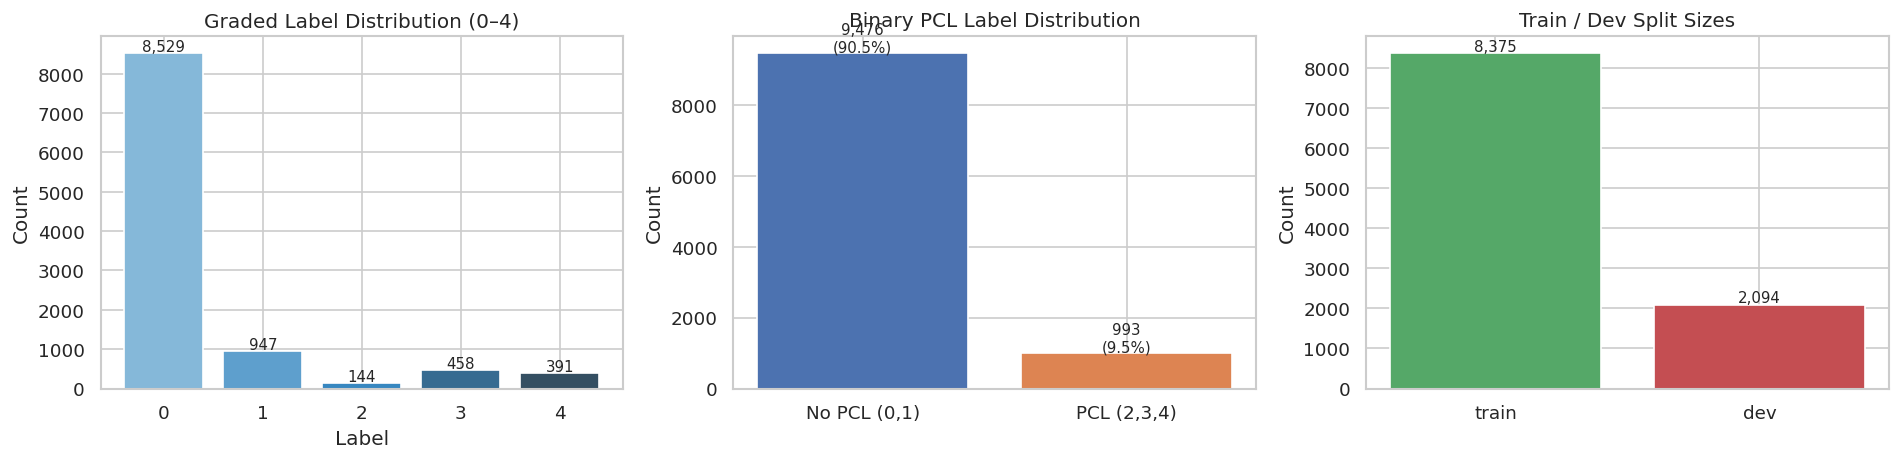

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Graded label distribution (0-4)
label_counts = df_split["label"].value_counts().sort_index()
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette("Blues_d", 5))
axes[0].set_title("Graded Label Distribution (0–4)")
axes[0].set_xlabel("Label"); axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", fontsize=9)

# 2. Binary PCL distribution
binary_counts = df_split["pcl"].value_counts().sort_index()
axes[1].bar(["No PCL (0,1)", "PCL (2,3,4)"], binary_counts.values,
            color=["#4c72b0", "#dd8452"])
axes[1].set_title("Binary PCL Label Distribution")
axes[1].set_ylabel("Count")
for bar, val in zip(axes[1].patches, binary_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}\n({val/len(df_split)*100:.1f}%)", ha="center", fontsize=9)

# 3. Train vs Dev split size
split_counts = df_split["split"].value_counts()
axes[2].bar(split_counts.index, split_counts.values, color=["#55a868", "#c44e52"])
axes[2].set_title("Train / Dev Split Sizes")
axes[2].set_ylabel("Count")
for bar, val in zip(axes[2].patches, split_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


In [13]:
print(f"\nClass imbalance ratio (No PCL : PCL): {binary_counts[0]/binary_counts[1]:.1f} : 1")


Class imbalance ratio (No PCL : PCL): 9.5 : 1


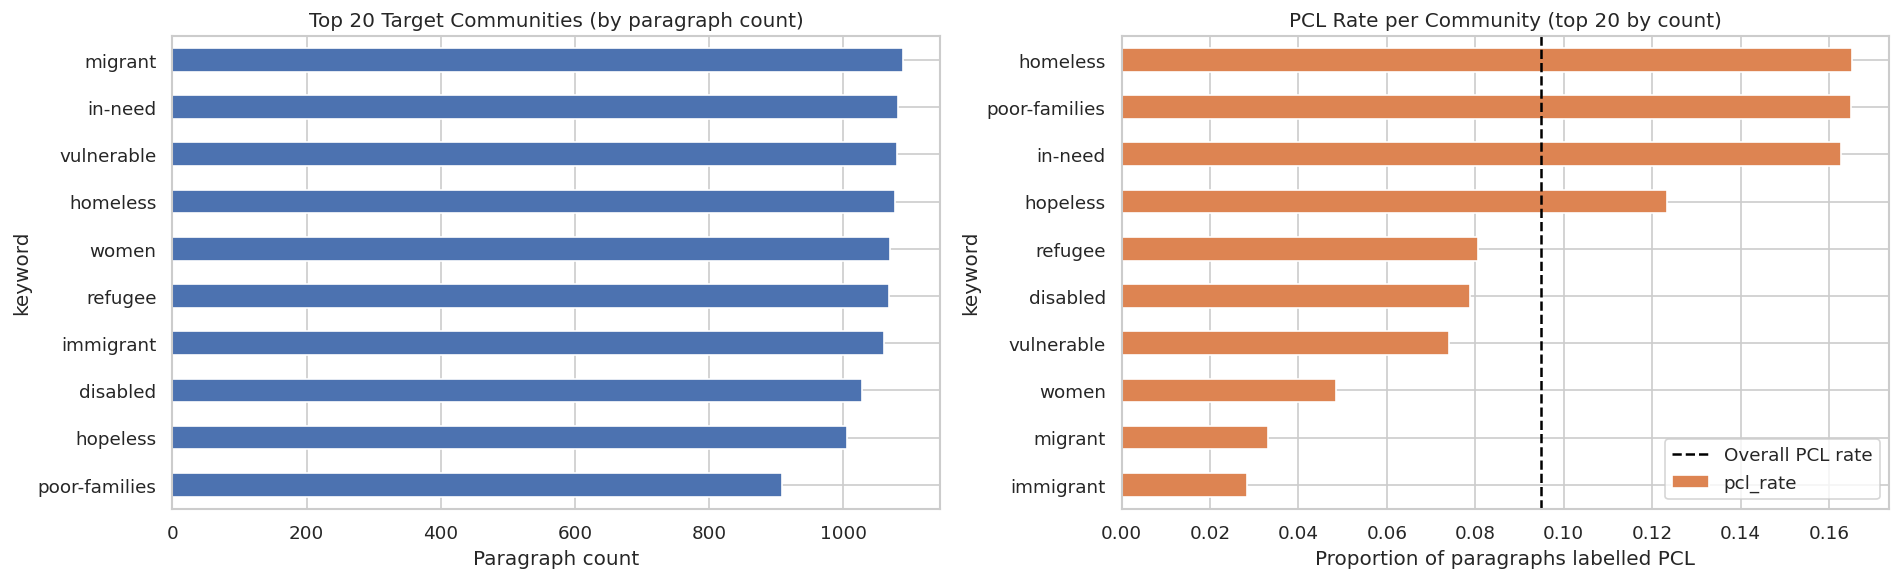

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top communities (keywords)
kw_pcl_rate = (
    df_split.groupby("keyword")["pcl"]
    .agg(count="count", pcl_rate="mean")
    .sort_values("count", ascending=False)
    .head(20)
)
kw_pcl_rate["count"].sort_values().plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("Top 20 Target Communities (by paragraph count)")
axes[0].set_xlabel("Paragraph count")

# PCL rate per community (top 20 by count)
kw_pcl_rate["pcl_rate"].sort_values().plot.barh(ax=axes[1], color="#dd8452")
axes[1].set_title("PCL Rate per Community (top 20 by count)")
axes[1].set_xlabel("Proportion of paragraphs labelled PCL")
axes[1].axvline(df_split["pcl"].mean(), color="black", linestyle="--", label="Overall PCL rate")
axes[1].legend()

plt.tight_layout()
plt.show()


### Technique 1: Statistical Profiling

Vocabulary size, type–token ratio, token-length distributions, and a scan for exact duplicates and noise artefacts. These structural properties determine hard constraints such as `max_length` and reveal data quality issues that must be resolved before training.

In [15]:
import re
from IPython.display import display

tok = lambda txt: re.findall(r'\b[a-z]+\b', str(txt).lower())

pcl_toks   = [t for txt in df_split[df_split.pcl==1]["text"] for t in tok(txt)]
nopcl_toks = [t for txt in df_split[df_split.pcl==0]["text"] for t in tok(txt)]
all_toks   = pcl_toks + nopcl_toks

pd.DataFrame({
    "Class":        ["No PCL", "PCL", "Overall"],
    "Paragraphs":   [df_split.pcl.eq(0).sum(), df_split.pcl.eq(1).sum(), len(df_split)],
    "Vocab":        [len(set(nopcl_toks)), len(set(pcl_toks)), len(set(all_toks))],
    "Total tokens": [len(nopcl_toks), len(pcl_toks), len(all_toks)],
    "TTR":          [round(len(set(nopcl_toks))/len(nopcl_toks),4),
                     round(len(set(pcl_toks))/len(pcl_toks),4),
                     round(len(set(all_toks))/len(all_toks),4)],
})


,Class,Paragraphs,Vocab,Total tokens,TTR
0,No PCL,9476,27572,404702,0.0681
1,PCL,993,7627,47615,0.1602
2,Overall,10469,29046,452317,0.0642


In [16]:
# Word-count stats per class
df_split["text_len_words"] = df_split["text"].str.split().str.len()

(df_split.groupby("pcl")["text_len_words"]
         .agg(Mean="mean", Median="median", Min="min", Max="max", Std="std")
         .round(1)
         .rename(index={0:"No PCL", 1:"PCL"}))


,Mean,Median,Min,Max,Std
pcl,,,,,
No PCL,47.9,42.0,1.0,909.0,28.6
PCL,53.6,47.0,6.0,512.0,32.8


In [17]:
class_counts = df_split["pcl"].value_counts()
class_percentages = (class_counts / len(df_split) * 100).round(1)
imbalance_ratio = round(class_counts[0] / class_counts[1], 1)
imbalance_df = pd.DataFrame({
    "Class": ["No PCL", "PCL"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values,
    "Imbalance Ratio (No PCL : PCL)": [f"{imbalance_ratio} : 1", "-"]
})
imbalance_df

,Class,Count,Percentage,Imbalance Ratio (No PCL : PCL)
0,No PCL,9476,90.5,9.5 : 1
1,PCL,993,9.5,-


In [18]:
# PCL span counts per keyword
(df_cat.groupby("keyword")
       .size()
       .sort_values(ascending=False)
       .head(20)
       .rename("span_count")
       .to_frame())


,span_count
keyword,
in-need,473
homeless,457
poor-families,439
hopeless,435
vulnerable,224
refugee,211
disabled,195
women,144
migrant,100


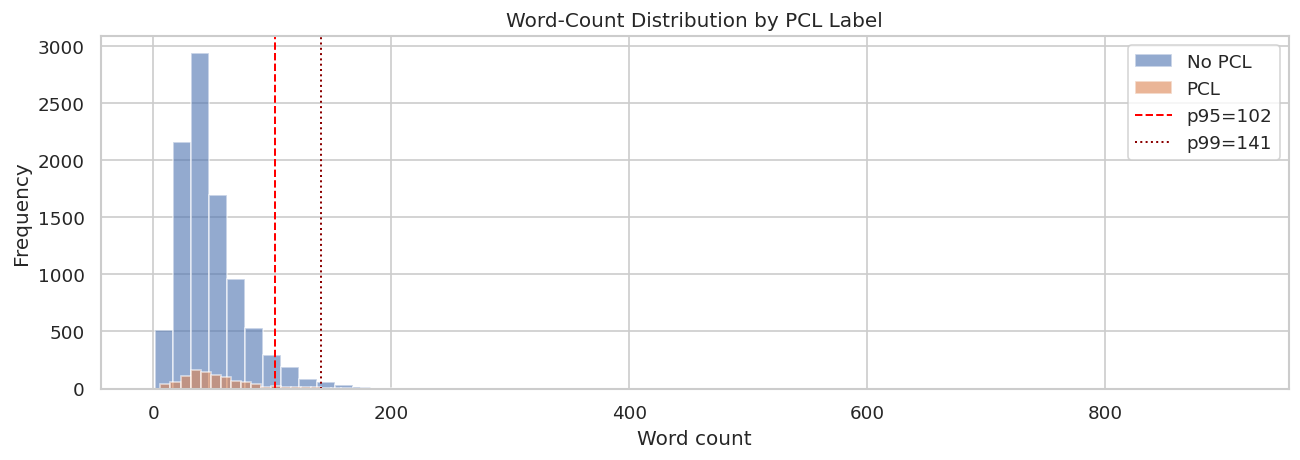

p95=102 words  |  p99=141 words


In [19]:
# Word-count histogram with p95 / p99 cut-offs
p95 = int(df_split["text_len_words"].quantile(0.95))
p99 = int(df_split["text_len_words"].quantile(0.99))

fig, ax = plt.subplots(figsize=(11, 4))
for v, c, lbl in [(0,"#4c72b0","No PCL"),(1,"#dd8452","PCL")]:
    ax.hist(df_split[df_split.pcl==v]["text_len_words"], bins=60, alpha=0.6, color=c, label=lbl)
ax.axvline(p95, color="red",     ls="--", lw=1.2, label=f"p95={p95}")
ax.axvline(p99, color="darkred", ls=":",  lw=1.2, label=f"p99={p99}")
ax.set(xlabel="Word count", ylabel="Frequency",
       title="Word-Count Distribution by PCL Label")
ax.legend(); plt.tight_layout()
plt.savefig("report/figures/wordcount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"p95={p95} words  |  p99={p99} words")


#### Duplicates and Noise

In [20]:
# Duplicate & leakage check
n_dup      = df_split["text"].duplicated().sum()
n_leakage  = len(set(df_train["text"]) & set(df_test["text"]))
dup_df     = df_split[df_split.duplicated(subset=["text"], keep=False)]
n_conflict = dup_df.groupby("text")["pcl"].nunique().gt(1).sum() if n_dup else 0

print(f"Exact duplicates:          {n_dup}  ({n_dup/len(df_split)*100:.2f}%)")
print(f"Train→Dev text leakage:    {n_leakage}")
print(f"Duplicates with label conflict: {n_conflict}")


Exact duplicates:          0  (0.00%)
Train→Dev text leakage:    0
Duplicates with label conflict: 0


In [21]:
# Noise artefact scan
patterns = {
    "HTML entities":    r'&\w+;',
    "URLs":             r'https?://\S+',
    "Long digit runs":  r'\b\d{4,}\b',
    "Non-ASCII":        r'[^\x00-\x7F]',
    "Double spaces":    r'  +',
}
rows = [{"Artefact": k,
         "Paragraphs": (n := df_split["text"].str.contains(v,regex=True).sum()),
         "%": round(n/len(df_split)*100,2)}
        for k,v in patterns.items()]
pd.DataFrame(rows)


,Artefact,Paragraphs,%
0,HTML entities,78,0.75
1,URLs,0,0.00
2,Long digit runs,1025,9.79
3,Non-ASCII,0,0.00
4,Double spaces,0,0.00


### Technique 2: Lexical Analysis

Comparing top unigrams and bigrams for PCL vs. non-PCL paragraphs, after removing stopwords. This reveals whether the model can exploit discriminative surface patterns or whether such shortcut features exist and could cause spurious correlations.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n, k=20):
    vec = CountVectorizer(ngram_range=(n,n), stop_words="english", max_features=5000)
    X   = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    return pd.Series(counts, index=vec.get_feature_names_out()).nlargest(k)

pcl_texts   = df_split[df_split.pcl==1]["text"].dropna().tolist()
nopcl_texts = df_split[df_split.pcl==0]["text"].dropna().tolist()

uni_pcl,  uni_nopcl = top_ngrams(pcl_texts,1), top_ngrams(nopcl_texts,1)
bi_pcl,   bi_nopcl  = top_ngrams(pcl_texts,2), top_ngrams(nopcl_texts,2)


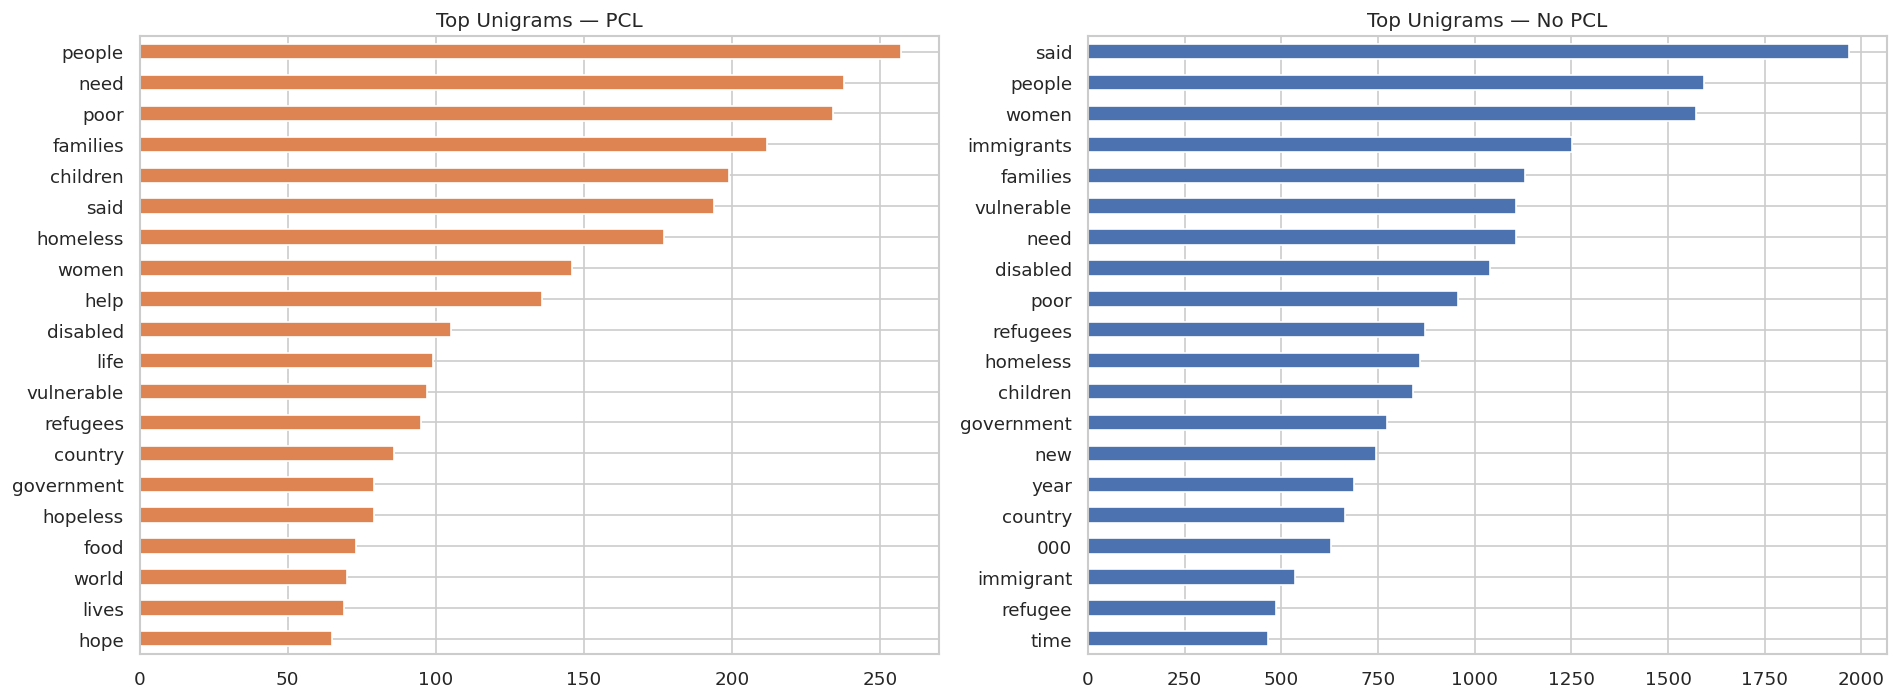

In [23]:
# Top-20 unigrams: PCL vs No-PCL
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
uni_pcl.sort_values().plot.barh(ax=axes[0], color="#dd8452")
axes[0].set_title("Top Unigrams — PCL")
uni_nopcl.sort_values().plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Top Unigrams — No PCL")
plt.tight_layout()
plt.savefig("report/figures/unigrams.png", dpi=150, bbox_inches="tight")
plt.show()


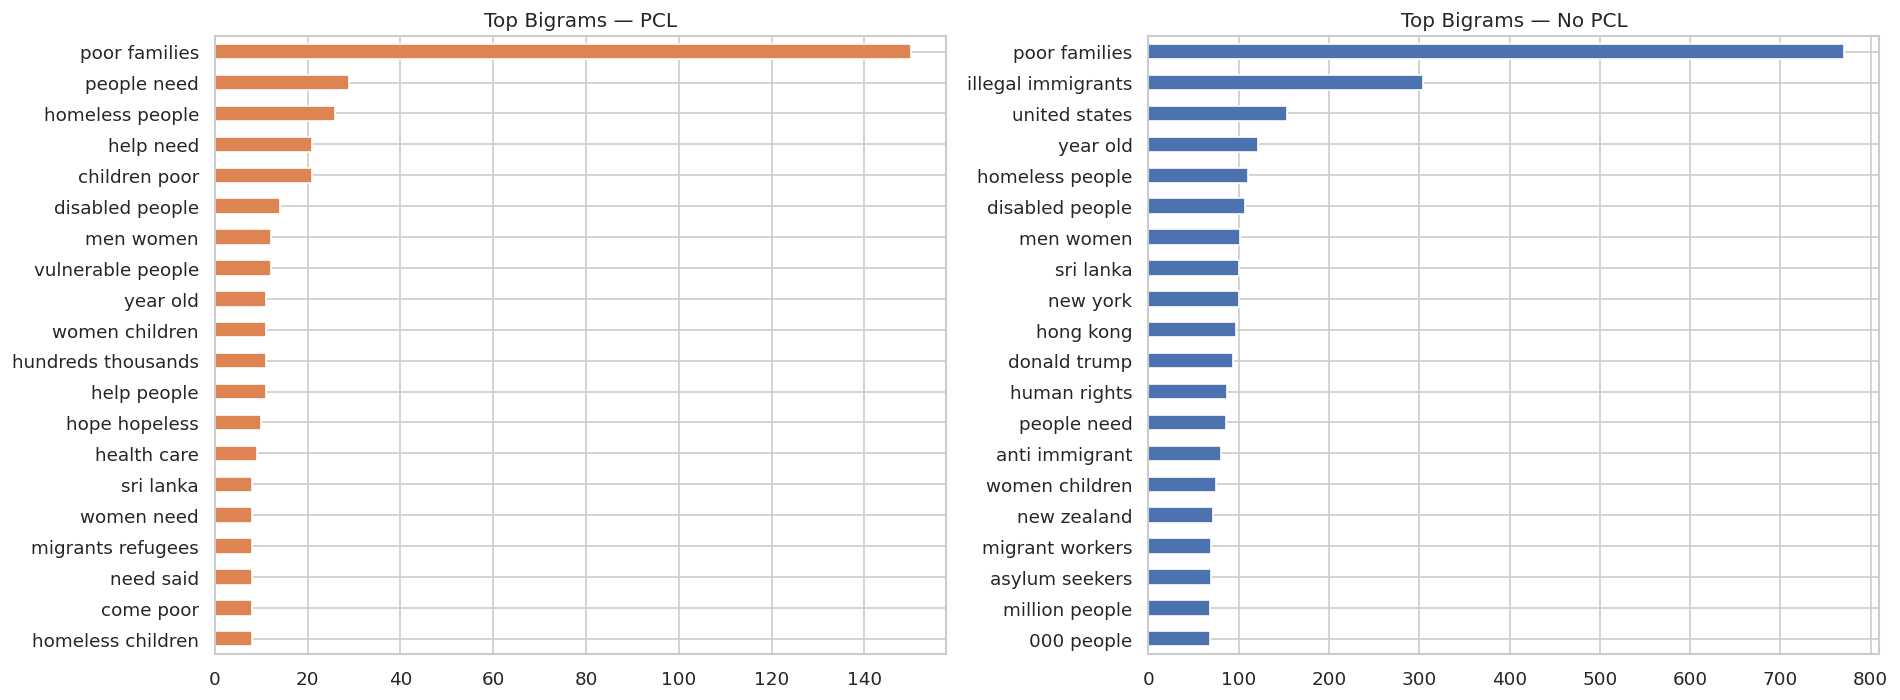

In [24]:
# Top-20 bigrams: PCL vs No-PCL
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bi_pcl.sort_values().plot.barh(ax=axes[0], color="#dd8452")
axes[0].set_title("Top Bigrams — PCL")
bi_nopcl.sort_values().plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Top Bigrams — No PCL")
plt.tight_layout()
plt.savefig("report/figures/bigrams.png", dpi=150, bbox_inches="tight")
plt.show()


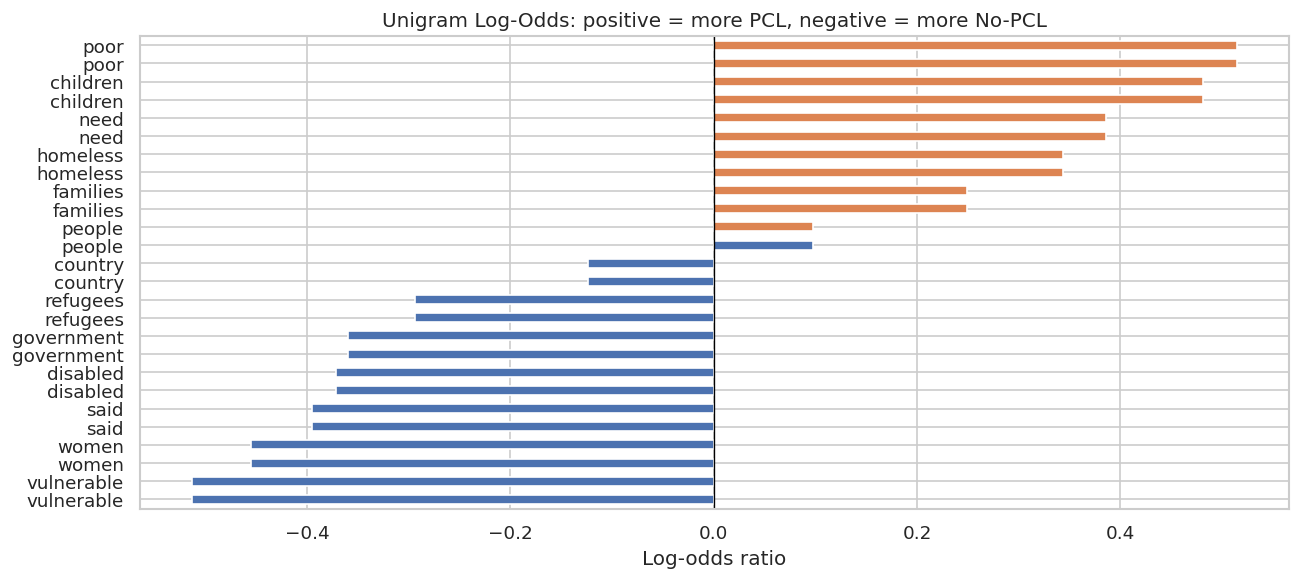

In [25]:
# Most distinctive unigrams by log-odds ratio (PCL vs No-PCL)
shared = uni_pcl.index.intersection(uni_nopcl.index)
log_odds = np.log((uni_pcl[shared] / uni_pcl[shared].sum()) /
                  (uni_nopcl[shared] / uni_nopcl[shared].sum()))

fig, ax = plt.subplots(figsize=(11, 5))
pd.concat([log_odds.nlargest(15), log_odds.nsmallest(15)]).sort_values().plot.barh(
    ax=ax, color=["#4c72b0"]*15 + ["#dd8452"]*15)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Unigram Log-Odds: positive = more PCL, negative = more No-PCL",
       xlabel="Log-odds ratio")
plt.tight_layout()
plt.savefig("report/figures/log_odds.png", dpi=150, bbox_inches="tight")
plt.show()


## Baseline Model and Novel Approach

### Baseline Model (RoBERTa-base)
Fine-tuned with standard cross-entropy, no imbalance handling, evaluated on the official dev split.


In [26]:
# Tokenise for RoBERTa-base
base_tok = AutoTokenizer.from_pretrained("roberta-base")
train_texts  = df_train["text"].fillna("").tolist()
test_texts   = df_test["text"].fillna("").tolist()
train_labels = df_train["pcl"].tolist()
test_labels  = df_test["pcl"].tolist()

base_train_ds = PCLDataset(tokenize(train_texts, base_tok), train_labels)
base_test_ds  = PCLDataset(tokenize(test_texts,  base_tok), test_labels)
print("Tokenisation done:", len(base_train_ds), "train /", len(base_test_ds), "dev")


Tokenisation done: 8375 train / 2094 dev


In [27]:
BASELINE_DIR = "models/baseline"

if os.path.exists(os.path.join(BASELINE_DIR, "config.json")):
    print(f"✓ Saved model found — loading baseline from {BASELINE_DIR}")
    base_model = AutoModelForSequenceClassification.from_pretrained(BASELINE_DIR)
    base_trainer = Trainer(
        model=base_model,
        args=TrainingArguments(
            output_dir="outputs/baseline",
            per_device_eval_batch_size=32,
            report_to="none",
        ),
        eval_dataset=base_test_ds,
        compute_metrics=compute_metrics,
    )
else:
    print("No saved model found — training baseline from scratch")
    base_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
    base_trainer = Trainer(
        model=base_model,
        args=TrainingArguments(
            output_dir="outputs/baseline",
            num_train_epochs=3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            eval_strategy="epoch",
            save_strategy="no",
            logging_steps=50,
            report_to="none",
            seed=42,
        ),
        train_dataset=base_train_ds,
        eval_dataset=base_test_ds,
        compute_metrics=compute_metrics,
    )
    base_trainer.train()
    os.makedirs(BASELINE_DIR, exist_ok=True)
    base_model.save_pretrained(BASELINE_DIR)
    base_tok.save_pretrained(BASELINE_DIR)
    print(f"Baseline model saved to {BASELINE_DIR}")

baseline_f1 = print_metrics(base_trainer, base_test_ds, test_labels, "Baseline (RoBERTa-base) — reported ≈ 0.48 F1")


✓ Saved model found — loading baseline from models/baseline


Loading weights:   4%|▍         | 9/201 [00:00<00:00, 437.54it/s, Materializing param=roberta.embeddings.word_embeddings.weight]      

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 918.52it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



── Baseline (RoBERTa-base) — reported ≈ 0.48 F1 ─────────────────────
  Precision (PCL): 0.6402
  Recall    (PCL): 0.5276
  F1        (PCL): 0.5785

              precision    recall  f1-score   support

      No PCL       0.95      0.97      0.96      1895
         PCL       0.64      0.53      0.58       199

    accuracy                           0.93      2094
   macro avg       0.80      0.75      0.77      2094
weighted avg       0.92      0.93      0.92      2094



### Proposed Model (DeBERTa-v3-base + Focal Loss)
Five deviations from the baseline:
1. **DeBERTa-v3-base encoder** — disentangled attention with enhanced mask decoder outperforms RoBERTa on classification tasks.
2. **Focal loss** ($\gamma=2$, $\alpha_1 = \sqrt{N_0/N_1} \approx 3\times$) — down-weights easy majority-class examples and concentrates gradient on hard minority-class samples. Class weight is applied as a **separate per-sample scalar** $\alpha_t$ and the focal factor $(1-p_t)^2$ is **not detached**, ensuring the loss has no degenerate constant-predictor stationary point. The output-projection bias is **initialised to the log-odds of the class prior** (`b = [0, log(n_pcl/n_nopcl)] ≈ [0, -2.2]`), anchoring $p(\text{PCL}) \approx 0.10$ from step 0 so focal gradients are correctly sized from the first update.
3. **Layer-wise LR decay (LLRD, $\lambda=0.9$)** — lower layers receive exponentially smaller LRs, preserving pre-trained representations while allowing the classification head to adapt at full base-LR.
4. **Cosine LR schedule with 6% warmup** — reaches full LR well before the epoch-1 evaluation checkpoint, then decays smoothly to reduce over-fitting.
5. **Keyword-stratified 90/10 internal split** with in-memory best-model tracking (early stopping patience=5) for honest generalisation.


In [28]:
# Keyword-stratified 90/10 internal split of the official train set
strat_key = df_train["pcl"].astype(str) + "_" + df_train["keyword"].astype(str)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(sss.split(df_train, strat_key))

df_int_train = df_train.iloc[train_idx].reset_index(drop=True)
df_int_val   = df_train.iloc[val_idx].reset_index(drop=True)

print(f"Internal train: {len(df_int_train)}  |  Internal val: {len(df_int_val)}")
print(f"PCL rate  train: {df_int_train.pcl.mean():.3f}  val: {df_int_val.pcl.mean():.3f}")
print(f"Keywords in train: {df_int_train.keyword.nunique()}  val: {df_int_val.keyword.nunique()}")


Internal train: 7537  |  Internal val: 838
PCL rate  train: 0.095  val: 0.094
Keywords in train: 10  val: 10


In [34]:
# Tokenise with DeBERTa-v3-base (requires sentencepiece)
prop_tok = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

int_train_ds = PCLDataset(
    tokenize(df_int_train["text"].fillna("").tolist(), prop_tok),
    df_int_train["pcl"].tolist()
)
int_val_ds = PCLDataset(
    tokenize(df_int_val["text"].fillna("").tolist(), prop_tok),
    df_int_val["pcl"].tolist()
)
dev_ds = PCLDataset(
    tokenize(test_texts, prop_tok),
    test_labels
)
print(f"Tokenised  int-train: {len(int_train_ds)}  int-val: {len(int_val_ds)}  dev: {len(dev_ds)}")


Tokenised  int-train: 7537  int-val: 838  dev: 2094


In [37]:

import re as _re
import copy
from transformers import TrainerCallback

# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.register_buffer("alpha", alpha)  # per-class weight tensor [w_0, w_1]

    def forward(self, logits, labels):
        # Always work in float32 — DeBERTa-v3 large logits overflow fp16
        logits_f = logits.float()

        # Per-sample CE with NO class weight: focal factor handles focus,
        # we apply alpha separately below.  Passing weight= into cross_entropy
        # while also multiplying by focal_factor double-compensates and creates
        # a degenerate stationary point at constant p ≈ class-prior.
        ce = nn.functional.cross_entropy(logits_f, labels, reduction="none")

        # p_t = probability assigned to the true class
        probs = torch.softmax(logits_f, dim=-1)
        pt    = probs.gather(1, labels.unsqueeze(1)).squeeze(1)

        # Focal factor — NOT detached.  Detaching freezes it to its current value
        # at each optimiser step; the resulting gradient has a stationary point at
        # a constant predictor (verified analytically: N0*w0*p^3 = N1*w1*(1-p)^3
        # which gives p ≈ 0.41 for this dataset — exactly what we observed).
        focal_factor = (1.0 - pt) ** self.gamma

        # Per-sample class weight alpha_t
        if self.alpha is not None:
            alpha_t = self.alpha.to(device=logits.device, dtype=torch.float32)[labels]
        else:
            alpha_t = torch.ones_like(ce)

        return (alpha_t * focal_factor * ce).mean()

n_nopcl = (df_int_train["pcl"] == 0).sum()
n_pcl   = (df_int_train["pcl"] == 1).sum()
# Exponent 0.5 = sqrt weighting.  Keeps the effective PCL weight at ~3×,
# strong enough to counteract imbalance without pusing the model toward
# all-PCL predictions.  Combined with non-detached focal (γ=2) this is
# sufficient — no need for the aggressive 0.75 exponent.
w_pcl   = (n_nopcl / n_pcl) ** 0.5
print(f"Class weight — No PCL: 1.000  PCL: {w_pcl:.3f}  (raw ratio: {n_nopcl/n_pcl:.1f})")
class_weights = torch.tensor([1.0, w_pcl], dtype=torch.float)
focal_loss_fn = FocalLoss(gamma=2.0, alpha=class_weights)

# ── Layer-wise LR Decay (LLRD) ─────────────────────────────────────────────────
def get_llrd_param_groups(model, base_lr, llrd=0.9, weight_decay=0.01):
    """
    Assign exponentially decaying LR to each transformer layer.
    Classifier/pooler → base_lr, layer N-1 → base_lr*llrd, ..., embeddings → base_lr*llrd^N.
    No weight-decay on bias / LayerNorm params (standard practice).
    """
    no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias",
                "LayerNorm.gamma", "LayerNorm.beta"}
    n_layers = model.config.num_hidden_layers  # 12

    def depth(name):
        if any(h in name for h in ("classifier", "pooler")):
            return n_layers + 1          # head — full LR
        if "encoder.LayerNorm" in name:
            return n_layers              # top encoder norm
        m = _re.search(r"encoder\.layer\.(\d+)\.", name)
        if m:
            return int(m.group(1)) + 1  # 1..n_layers
        return 0                         # embeddings

    grouped: dict = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        d    = depth(name)
        lr   = base_lr * (llrd ** (n_layers + 1 - d))
        wd   = 0.0 if any(nd in name for nd in no_decay) else weight_decay
        key  = (round(lr, 12), wd)
        grouped.setdefault(key, []).append(param)

    return [{"params": ps, "lr": lr, "weight_decay": wd}
            for (lr, wd), ps in grouped.items()]

# ── Best-model callback ────────────────────────────────────────────────────────
class BestF1Callback(TrainerCallback):
    """
    Saves in-memory model snapshot whenever val F1 improves.
    Logs p(PCL) distribution each epoch so we can see if the model is learning
    or collapsing before early stopping fires.
    """
    def __init__(self, model, patience=5):
        self.model     = model
        self.best_f1   = -1.0
        self.best_state= None
        self.patience  = patience
        self._no_impr  = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        f1 = (metrics or {}).get("eval_f1_pcl", -1.0)

        # ── p(PCL) distribution diagnostic ────────────────────────────────────
        # Pull raw logits from the last predict pass stored in metrics
        # (not always available) — fall back to a note if absent
        preds_key = [k for k in (metrics or {}) if "predictions" in k]
        if not preds_key:
            print(f"  [diag] eval_f1_pcl={f1:.4f}  (p(PCL) dist unavailable in metrics)")
        # ── end diagnostic ─────────────────────────────────────────────────────

        if f1 > self.best_f1:
            self.best_f1    = f1
            self.best_state = copy.deepcopy(self.model.state_dict())
            self._no_impr   = 0
            print(f"  ↑ New best val F1 = {f1:.4f}")
        else:
            self._no_impr += 1
            print(f"  No improvement ({self._no_impr}/{self.patience})")
            if self._no_impr >= self.patience:
                control.should_training_stop = True
                print("  Early stopping triggered.")

    def restore_best(self):
        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
            print(f"Restored best model (val F1 = {self.best_f1:.4f})")

# ── FocalTrainer with LLRD optimizer ──────────────────────────────────────────
class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = focal_loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

    def create_optimizer(self):
        """Replace default optimizer with LLRD AdamW."""
        if self.optimizer is None:
            param_groups = get_llrd_param_groups(
                self.model,
                base_lr=self.args.learning_rate,
                llrd=0.9,
                weight_decay=self.args.weight_decay,
            )
            self.optimizer = torch.optim.AdamW(param_groups, eps=1e-6)
        return self.optimizer

    def evaluation_loop(self, dataloader, description, prediction_loss_only=None,
                        ignore_keys=None, metric_key_prefix="eval"):
        """Override to log p(PCL) distribution after every eval pass."""
        output = super().evaluation_loop(
            dataloader, description,
            prediction_loss_only=prediction_loss_only,
            ignore_keys=ignore_keys,
            metric_key_prefix=metric_key_prefix,
        )
        if output.predictions is not None:
            logits = output.predictions.astype(float)
            e = np.exp(logits - logits.max(axis=-1, keepdims=True))
            probs_pcl = e[:, 1] / e.sum(axis=-1)
            above_t = (probs_pcl >= PCL_THRESHOLD).mean() * 100
            print(f"  [diag] p(PCL): min={probs_pcl.min():.3f}  "
                  f"mean={probs_pcl.mean():.3f}  max={probs_pcl.max():.3f}  "
                  f"above threshold ({PCL_THRESHOLD}): {above_t:.1f}%")
        return output


Class weight — No PCL: 1.000  PCL: 3.089  (raw ratio: 9.5)


In [39]:

import math

PROPOSED_DIR  = "models/proposed"
NUM_EPOCHS    = 8
BATCH         = 16
GRAD_ACCUM    = 2      # effective batch = 32
BASE_LR       = 2e-5   # 2e-5 — LLRD already decays lower layers; no need to cut global LR
# bf16 is faster than fp32 on Ampere+ GPUs and far safer than fp16 for DeBERTa-v3
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"Precision: {'bf16' if use_bf16 else 'fp32'}  (fp16 disabled — unstable with DeBERTa-v3)")

if os.path.exists(os.path.join(PROPOSED_DIR, "config.json")):
    print(f"✓ Saved model found — loading proposed model from {PROPOSED_DIR}")
    prop_model = AutoModelForSequenceClassification.from_pretrained(PROPOSED_DIR)
    prop_trainer = FocalTrainer(
        model=prop_model,
        args=TrainingArguments(
            output_dir="outputs/proposed",
            per_device_eval_batch_size=32,
            fp16=False, bf16=use_bf16,
            report_to="none",
        ),
        eval_dataset=int_val_ds,
        compute_metrics=compute_metrics,
    )
else:
    print("No saved model found — training proposed model from scratch")
    prop_model = AutoModelForSequenceClassification.from_pretrained(
        "microsoft/deberta-v3-base", num_labels=2
    )

    # ── Bias initialisation (prior log-odds) ──────────────────────────────────
    # DebertaV2ForSequenceClassification has:
    #   self.pooler  = ContextPooler  (dense → tanh)
    #   self.classifier = nn.Linear(hidden_size, num_labels)   ← final logit layer
    # Setting bias[1] = log(n_pcl/n_nopcl) anchors p(PCL) ≈ 0.10 at step 0 so
    # that focal gradients are correctly tiny for easy negatives and large for
    # positives from the first update onwards.
    prior_logit = math.log(n_pcl / n_nopcl)   # ≈ -2.2 for 10:1 imbalance
    with torch.no_grad():
        prop_model.classifier.bias.data.zero_()
        prop_model.classifier.bias.data[1] = prior_logit
    print(f"Bias init: [0.00, {prior_logit:.3f}]  →  p(PCL) at init ≈ {n_pcl/(n_nopcl+n_pcl):.3f}")
    # ── end bias init ─────────────────────────────────────────────────────────

    # ── LLRD sanity check ─────────────────────────────────────────────────────
    _diag_groups = get_llrd_param_groups(prop_model, BASE_LR, llrd=0.9)
    _diag_by_lr = {}
    for g in _diag_groups:
        lr = g["lr"]
        for name, param in prop_model.named_parameters():
            if any(p is param for p in g["params"]):
                _diag_by_lr.setdefault(lr, []).append(name)
                break
    print(f"\nLLRD groups ({len(_diag_groups)} total) — sample param per LR bucket:")
    for lr in sorted(_diag_by_lr, reverse=True):
        print(f"  lr={lr:.2e}  →  {_diag_by_lr[lr][0]}")
    print()
    # ── end diagnostic ────────────────────────────────────────────────────────

    # 6% warmup: model reaches full LR well before epoch-1 eval (~113 steps).
    # 20% warmup kept the model inside the ramp at epoch 1 (235 < 376 steps),
    # meaning the first checkpoint always showed F1=0 regardless of the loss fn.
    effective_batch   = BATCH * GRAD_ACCUM
    steps_per_epoch   = len(int_train_ds) // effective_batch
    total_steps       = steps_per_epoch * NUM_EPOCHS
    warmup_steps      = int(0.06 * total_steps)  # 6% warmup: clears ramp before epoch-1 eval
    print(f"effective_batch={effective_batch}  steps/epoch={steps_per_epoch}  "
          f"total={total_steps}  warmup={warmup_steps}")

    best_cb = BestF1Callback(prop_model, patience=5)

    prop_trainer = FocalTrainer(
        model=prop_model,
        args=TrainingArguments(
            output_dir="outputs/proposed",
            num_train_epochs=NUM_EPOCHS,
            per_device_train_batch_size=BATCH,
            per_device_eval_batch_size=32,
            gradient_accumulation_steps=GRAD_ACCUM,  # effective batch = 32
            learning_rate=BASE_LR,
            warmup_steps=warmup_steps,               # 6% warmup
            weight_decay=0.01,
            max_grad_norm=1.0,
            lr_scheduler_type="cosine",              # cosine decay after warmup
            fp16=False,                              # CRITICAL: fp16 causes NaN with DeBERTa-v3
            bf16=use_bf16,                           # safe alternative on Ampere+ GPUs
            eval_strategy="epoch",
            save_strategy="no",
            load_best_model_at_end=False,
            logging_steps=50,
            report_to="none",
            seed=42,
        ),
        train_dataset=int_train_ds,
        eval_dataset=int_val_ds,
        compute_metrics=compute_metrics,
        callbacks=[best_cb],
    )
    prop_trainer.train()

    # Restore in-memory best (safe — no file I/O, no gamma/beta key mismatch)
    best_cb.restore_best()

    os.makedirs(PROPOSED_DIR, exist_ok=True)
    prop_model.save_pretrained(PROPOSED_DIR)
    prop_tok.save_pretrained(PROPOSED_DIR)
    print(f"Proposed model saved to {PROPOSED_DIR}")

proposed_f1 = print_metrics(prop_trainer, dev_ds, test_labels, "Proposed (DeBERTa-v3-base + Focal Loss)")


Precision: bf16  (fp16 disabled — unstable with DeBERTa-v3)
No saved model found — training proposed model from scratch


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1105.04it/s, Materializing param=deberta.encoder.rel_embeddings.weight]                     
DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
pooler.dense.weight                     | MI

Bias init: [0.00, -2.256]  →  p(PCL) at init ≈ 0.095

LLRD groups (28 total) — sample param per LR bucket:
  lr=2.00e-05  →  pooler.dense.weight
  lr=1.80e-05  →  deberta.encoder.layer.11.attention.self.query_proj.weight
  lr=1.62e-05  →  deberta.encoder.layer.10.attention.self.query_proj.weight
  lr=1.46e-05  →  deberta.encoder.layer.9.attention.self.query_proj.weight
  lr=1.31e-05  →  deberta.encoder.layer.8.attention.self.query_proj.weight
  lr=1.18e-05  →  deberta.encoder.layer.7.attention.self.query_proj.weight
  lr=1.06e-05  →  deberta.encoder.layer.6.attention.self.query_proj.weight
  lr=9.57e-06  →  deberta.encoder.layer.5.attention.self.query_proj.weight
  lr=8.61e-06  →  deberta.encoder.layer.4.attention.self.query_proj.weight
  lr=7.75e-06  →  deberta.encoder.layer.3.attention.self.query_proj.weight
  lr=6.97e-06  →  deberta.encoder.layer.2.attention.self.query_proj.weight
  lr=6.28e-06  →  deberta.encoder.layer.1.attention.self.query_proj.weight
  lr=5.65e-06  →  deberta.en

Epoch,Training Loss,Validation Loss,F1 Pcl
1,0.388801,0.183190,0.000000
2,0.359806,0.171263,0.000000
3,0.368421,0.178835,0.000000
4,0.373553,0.170077,0.000000
5,0.323265,0.170278,0.000000
6,0.354342,0.170342,0.000000


  [diag] p(PCL): min=0.333  mean=0.333  max=0.333  above threshold (0.5): 0.0%
  [diag] eval_f1_pcl=0.0000  (p(PCL) dist unavailable in metrics)
  ↑ New best val F1 = 0.0000
  [diag] p(PCL): min=0.415  mean=0.415  max=0.415  above threshold (0.5): 0.0%
  [diag] eval_f1_pcl=0.0000  (p(PCL) dist unavailable in metrics)
  No improvement (1/5)
  [diag] p(PCL): min=0.343  mean=0.344  max=0.344  above threshold (0.5): 0.0%
  [diag] eval_f1_pcl=0.0000  (p(PCL) dist unavailable in metrics)
  No improvement (2/5)
  [diag] p(PCL): min=0.400  mean=0.400  max=0.400  above threshold (0.5): 0.0%
  [diag] eval_f1_pcl=0.0000  (p(PCL) dist unavailable in metrics)
  No improvement (3/5)
  [diag] p(PCL): min=0.387  mean=0.387  max=0.387  above threshold (0.5): 0.0%
  [diag] eval_f1_pcl=0.0000  (p(PCL) dist unavailable in metrics)
  No improvement (4/5)
  [diag] p(PCL): min=0.405  mean=0.405  max=0.405  above threshold (0.5): 0.0%
  [diag] eval_f1_pcl=0.0000  (p(PCL) dist unavailable in metrics)
  No impr

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.91it/s]


Proposed model saved to models/proposed


  [diag] p(PCL): min=0.333  mean=0.333  max=0.333  above threshold (0.5): 0.0%

── Proposed (DeBERTa-v3-base + Focal Loss) ─────────────────────
  Precision (PCL): 0.0000
  Recall    (PCL): 0.0000
  F1        (PCL): 0.0000

              precision    recall  f1-score   support

      No PCL       0.90      1.00      0.95      1895
         PCL       0.00      0.00      0.00       199

    accuracy                           0.90      2094
   macro avg       0.45      0.50      0.48      2094
weighted avg       0.82      0.90      0.86      2094



In [40]:
print("── Results Summary ────────────────────────────────────")
print(f"  Baseline  F1 (PCL): {baseline_f1:.4f}   (reported ≈ 0.48)")
print(f"  Proposed  F1 (PCL): {proposed_f1:.4f}")
print(f"  Δ F1:               {proposed_f1 - baseline_f1:+.4f}")


── Results Summary ────────────────────────────────────
  Baseline  F1 (PCL): 0.5785   (reported ≈ 0.48)
  Proposed  F1 (PCL): 0.0000
  Δ F1:               -0.5785
